In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#Load RSV REDCap info from which we will be subsampling
rsv_redcap = pd.read_csv("example.csv")

In [61]:
#convert dob and sample date to datetime format 
rsv_redcap['dob_corr'] = pd.to_datetime(rsv_redcap['dob'])
#convert sample date to datetime format
rsv_redcap['sample_date_corr'] = pd.to_datetime(rsv_redcap['sample_date'])

In [62]:
#Restrict sampling from desired date
rsv_redcap_range = rsv_redcap[
    (rsv_redcap['sample_date_corr'] >= "2024-11-01") & 
    (rsv_redcap['sample_date_corr'] <= "2025-03-01")]

In [229]:
#Listing to see if there are any duplicate MRNS (i.e. same patient different sample)
dupes = rsv_redcap_range[rsv_redcap_range["mrn"].duplicated(keep=False)] #71 samples listed
dupes["mrn"].nunique() #33 patients in this dataset had multiple samples

33

In [230]:
#Only keep unique patients (w/ no duplicate samples), by keeping the first mrn match 
rsv_redcap_range_uniq = rsv_redcap_range.drop_duplicates(subset="mrn", keep="first")

In [232]:
#Generating age (in years) by calculating the difference between sample date and date of birth
rsv_redcap_range_uniq['age_yrs'] = ((rsv_redcap_range_uniq['sample_date_corr'] - rsv_redcap_range_uniq['dob_corr']).dt.days)/365.25
#Restrict sampling group by only pediatric specimen (note that sometimes LCH will collect samples with patient age >18)
rsv_redcap_range_uniq = rsv_redcap_range_uniq[rsv_redcap_range_uniq['age_yrs'] <=18]

/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_70539/2945274496.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rsv_redcap_range_uniq['age_yrs'] = ((rsv_redcap_range_uniq['sample_date_corr'] - rsv_redcap_range_uniq['dob_corr']).dt.days)/365.25


In [116]:
#Generating age (in months) by calculating the difference between sample date and date of birth
#rsv_redcap_range['age_yrs'] = ((rsv_redcap_range['sample_date_corr'] - rsv_redcap_range['dob_corr']).dt.days/30)

In [234]:
#Age Group Stratification (if using CPGME conventional age group)
#Can also change this to conventional RSV age groups (0-3 months, 3-6 months, 6-12 months, 1-2 years, 2-5 years, 5-10 years, and 10-18 years)
rsv_redcap_range_uniq['Age Group'] =''
rsv_redcap_range_uniq['Age Group'] = np.where((rsv_redcap_range_uniq['age_yrs'] >= 0) & 
                                      (rsv_redcap_range_uniq['age_yrs'] < 1), 
                                      '0-1 years', rsv_redcap_range_uniq['Age Group'])
rsv_redcap_range_uniq['Age Group'] = np.where((rsv_redcap_range_uniq['age_yrs'] >= 1) & 
                                      (rsv_redcap_range_uniq['age_yrs'] < 5), 
                                      '1-5 years', rsv_redcap_range_uniq['Age Group'])
rsv_redcap_range_uniq['Age Group'] = np.where((rsv_redcap_range_uniq['age_yrs'] >= 5) & 
                                      (rsv_redcap_range_uniq['age_yrs'] < 12), 
                                      '5 - 12 years', rsv_redcap_range_uniq['Age Group'])
rsv_redcap_range_uniq['Age Group'] = np.where((rsv_redcap_range_uniq['age_yrs'] >= 12) & 
                                      (rsv_redcap_range_uniq['age_yrs'] < 18), 
                                      '12 - 18 years', rsv_redcap_range_uniq['Age Group'])

In [235]:
rsv_redcap_range_uniq["sample_date"] = pd.to_datetime(rsv_redcap_range_uniq["sample_date"])
#making empty subsample dataframe
subsample= pd.DataFrame()
#Identify sample distribution by month of interest
rsv_redcap_range_uniq["sampling_period"] = rsv_redcap_range_uniq["sample_date"].dt.to_period("M")
#List out age group per sampling period
subsample_bucket = rsv_redcap_range_uniq.groupby(["sampling_period","Age Group"]).size().reset_index(name="sample_number").sort_values(["sampling_period","Age Group"])
#Calculate 10% subsample per each bucket and feed this into loop
subsample_bucket['10_percent_subsample'] = subsample_bucket['sample_number']/10
#Round the numbers into integers
subsample_bucket['10_percent_subsample'] = subsample_bucket['10_percent_subsample'].apply(np.floor)

In [237]:
#List the number of subsampled specimen you should anticipate from sampling loop
subsample_bucket['10_percent_subsample'].sum()

105.0

In [238]:
#Listing the overal sex distribution in the RSV REDCap to incorporate a weight into the subsampling method
sex_dist = rsv_redcap_range["sex"].value_counts(normalize=True)
sex_dist

2    0.526770
1    0.472366
3    0.000864
Name: sex, dtype: float64

In [239]:
# Randomly select 10% of your data
results = []

for _, row in subsample_bucket.iterrows():
    sampling_period = row["sampling_period"]
    age_group = row["Age Group"]
    size = row["10_percent_subsample"]

    df = rsv_redcap_range[
        (rsv_redcap_range["sampling_period"] == sampling_period) &
        (rsv_redcap_range["Age Group"] == age_group)
    ]

    if len(df) == 0:
        continue
        
    #add desired proportional sex based on total RSV REDCap if having difficulty achieving balanced sex distr.
    #df["weight"] = df["sex"].map(sex_weights)


    n_sample = min(len(df), int(size))

    sampled = df.sample(n=n_sample, random_state=None) # add weights="weight" for sex distribution (only if needed)
    results.append(sampled)

In [250]:
subsampled_fin = pd.concat(results,ignore_index=True)

# Rough checks Before you proceed with subsampled batch

Text(0.5, 1.0, 'LCH Age Distribution')

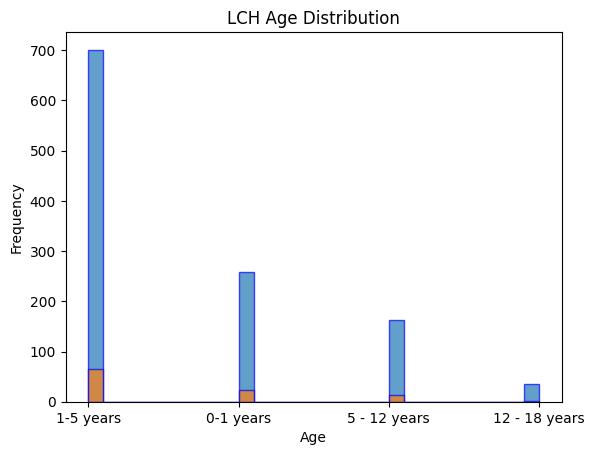

In [241]:
#Rough Check #1
#Ensure that the age distrubtion matches the age distribution of your total dataset
plt.hist(rsv_redcap_range['Age Group'], bins=30, edgecolor='blue', alpha=0.7)
plt.hist(subsampled_fin['Age Group'], bins=30, edgecolor='blue', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("LCH Age Distribution")

Text(0.5, 1.0, 'LCH Age Distribution')

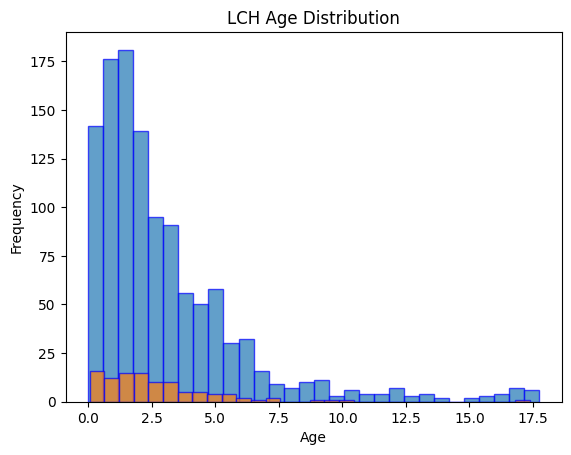

In [242]:
#Rough Check #1
#Ensure that the age distrubtion matches the age distribution of your total dataset
plt.hist(rsv_redcap_range['age_yrs'], bins=30, edgecolor='blue', alpha=0.7)
plt.hist(subsampled_fin['age_yrs'], bins=30, edgecolor='blue', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("LCH Age Distribution")

In [243]:
#Rough Check #2
#Ensure that the sex distribution matches the age distribution of your total dataset
subsampled_fin['sex']

#checking sex distribution in total set
proportion_table_redcap = rsv_redcap_range['sex'].value_counts(normalize=True)
proportion_table_redcap 

2    0.526770
1    0.472366
3    0.000864
Name: sex, dtype: float64

In [244]:
#checking sex distribution in subsampled set
#rerun sampling if sex distribution deviates too much (alternatively, add weight distribution back in code)
proportion_table_sub = subsampled_fin['sex'].value_counts(normalize=True)
proportion_table_sub

2    0.571429
1    0.428571
Name: sex, dtype: float64

In [247]:
monthly_counts1 = rsv_redcap_range["sampling_period"].value_counts().sort_index()
monthly_counts2 = subsampled_fin["sampling_period"].value_counts().sort_index()

# Combine monthly counts into one dataframe for overlay plot
monthly_compare = pd.DataFrame({"RSV REDCap": monthly_counts1, "Subsampled pool": monthly_counts2}).fillna(0)

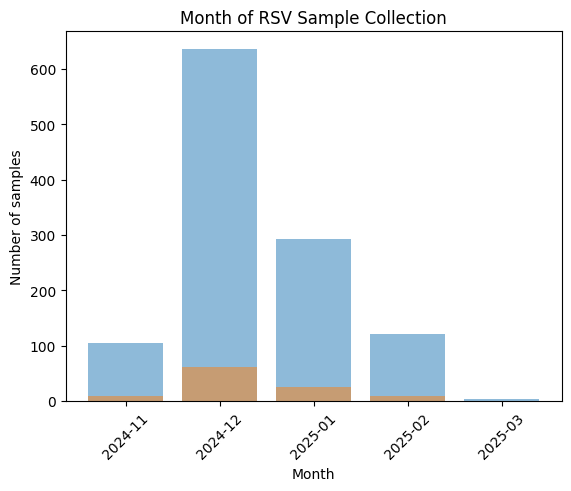

In [248]:
plt.bar(monthly_compare.index.astype(str), comparison["RSV REDCap"], alpha=0.5)
plt.bar(monthly_compare.index.astype(str), comparison["Subsampled pool"], alpha=0.5)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of samples")
plt.title("Month of RSV Sample Collection")
plt.show()

# Proceed to Save REDCap file only if "Rough Checks" look correct

In [249]:
#If age, sex, and monthly distribution look correct, save REDCap file for final selection
subsampled_fin.to_csv("example-output.csv")